In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")


In [3]:
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")
trader.columns = trader.columns.str.strip().str.lower().str.replace(" ", "_")


In [4]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['timestamp'].dt.date

trader['timestamp_ist'] = pd.to_datetime(trader['timestamp_ist'], dayfirst=True)
trader['date'] = trader['timestamp_ist'].dt.date


In [5]:
merged = trader.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

merged['classification'].value_counts()


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [6]:
merged.groupby('classification')['closed_pnl'] \
      .agg(['count','mean','median','std']) \
      .sort_values('mean', ascending=False)


,count,mean,median,std
classification,,,,
Extreme Greed,39992,67.892861,0.0,766.828294
Fear,61837,54.290400,0.0,935.355438
Greed,50303,42.743559,0.0,1116.028390
Extreme Fear,21400,34.537862,0.0,1136.056091
Neutral,37686,34.307718,0.0,517.122220


In [7]:
merged['win'] = merged['closed_pnl'] > 0

merged.groupby('classification')['win'].mean().sort_values(ascending=False)


classification
Extreme Greed    0.464943
Fear             0.420768
Neutral          0.396991
Greed            0.384828
Extreme Fear     0.370607
Name: win, dtype: float64

In [8]:
merged['date'] = pd.to_datetime(merged['date'])

trades_per_day = (
    merged.groupby(['date','classification'])
    .size()
    .reset_index(name='trade_count')
)

trades_per_day.groupby('classification')['trade_count'].mean()


classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trade_count, dtype: float64

In [9]:
merged.groupby('classification')['size_usd'].mean()


classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

In [10]:
merged.groupby(['classification','side']).size().unstack()


side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [11]:
daily_pnl = (
    merged.groupby(['account','date','classification'])['closed_pnl']
    .sum()
    .reset_index()
)

daily_pnl.groupby('classification')['closed_pnl'] \
         .agg(['mean','median','std'])


,mean,median,std
classification,,,
Extreme Fear,4619.439053,218.377399,29534.839183
Extreme Greed,5161.922644,418.319862,27496.863832
Fear,5328.818161,107.892532,31659.771538
Greed,3318.100730,158.214922,30599.040173
Neutral,3438.618818,167.551743,17447.863645


In [12]:
trade_counts = merged.groupby('account').size()
threshold = trade_counts.median()

merged['activity_segment'] = merged['account'].map(
    lambda x: 'High Activity' if trade_counts[x] > threshold else 'Low Activity'
)


In [13]:
merged.groupby(['activity_segment','classification'])['closed_pnl'] \
      .mean() \
      .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
activity_segment,,,,,
High Activity,34.163353,62.870911,51.323784,25.004641,34.579701
Low Activity,35.941979,103.264685,80.835791,210.210287,31.845656


In [14]:
avg_size = merged.groupby('account')['size_usd'].mean()
size_threshold = avg_size.median()

merged['size_segment'] = merged['account'].map(
    lambda x: 'Large Size' if avg_size[x] > size_threshold else 'Small Size'
)


In [15]:
merged.groupby(['size_segment','classification'])['closed_pnl'] \
      .mean() \
      .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
size_segment,,,,,
Large Size,34.584844,169.895839,101.641443,103.165165,90.484560
Small Size,34.506790,42.771183,27.176235,13.713519,9.008249


In [16]:
account_vol = merged.groupby('account')['closed_pnl'].std()
vol_threshold = account_vol.median()

merged['consistency_segment'] = merged['account'].map(
    lambda x: 'High Vol' if account_vol[x] > vol_threshold else 'Low Vol'
)


In [17]:
merged.groupby(['consistency_segment','classification'])['closed_pnl'] \
      .mean() \
      .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
consistency_segment,,,,,
High Vol,69.751090,207.924145,97.881284,91.713791,83.021460
Low Vol,1.288923,38.089393,8.716866,17.007976,3.493386


In [18]:
merged.groupby(['consistency_segment','classification'])['win'] \
      .mean() \
      .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
consistency_segment,,,,,
High Vol,0.349947,0.311912,0.427387,0.364822,0.451582
Low Vol,0.390115,0.497513,0.413847,0.395342,0.362459


In [19]:
merged.groupby(['consistency_segment','classification'])['size_usd'] \
      .mean() \
      .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
consistency_segment,,,,,
High Vol,5969.382714,9960.061153,11462.829898,12748.599069,9048.470890
Low Vol,4764.646760,1654.802432,4003.525786,2051.980999,2084.400067


In [20]:
daily_pnl = (
    merged.groupby(['account','date','classification'])['closed_pnl']
    .sum()
    .reset_index()
)

daily_pnl['consistency_segment'] = daily_pnl['account'].map(
    lambda x: 'High Vol' if account_vol[x] > vol_threshold else 'Low Vol'
)


In [21]:
daily_pnl.groupby(['consistency_segment','classification'])['closed_pnl'] \
         .mean() \
         .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
consistency_segment,,,,,
High Vol,9176.241461,6080.048553,9548.258820,4620.082205,6588.474805
Low Vol,175.150285,4391.467336,861.175111,1844.805903,420.006830


In [22]:
daily_pnl.groupby(['consistency_segment','classification'])['closed_pnl'] \
         .median() \
         .unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
consistency_segment,,,,,
High Vol,503.31943,162.623093,0.000000,0.000000,0.000000
Low Vol,142.99159,588.548818,157.192454,388.771124,254.607439


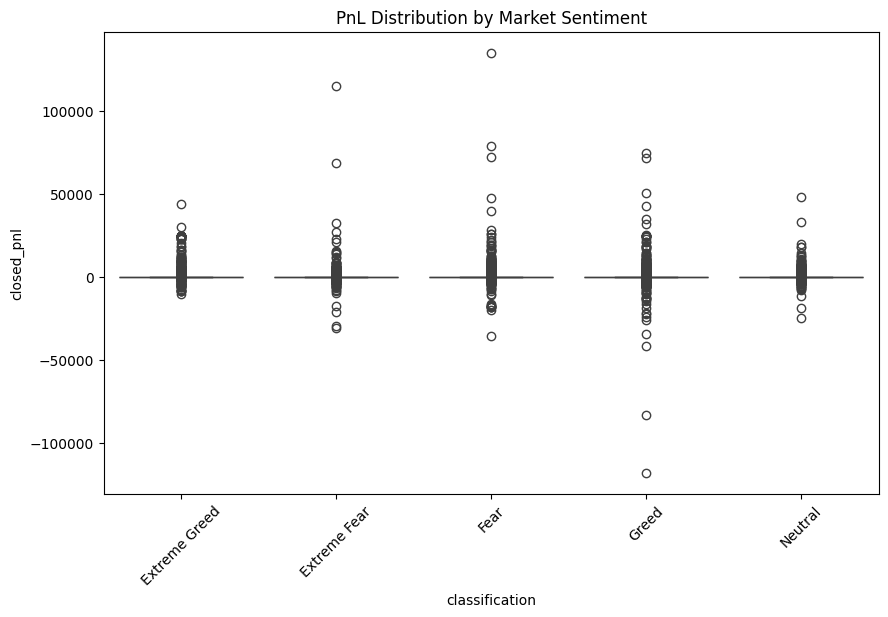

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x='classification', y='closed_pnl')
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.show()


In [24]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")
trader.columns = trader.columns.str.strip().str.lower().str.replace(" ", "_")

sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['timestamp'].dt.date

trader['timestamp_ist'] = pd.to_datetime(trader['timestamp_ist'], dayfirst=True)
trader['date'] = trader['timestamp_ist'].dt.date

merged = trader.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)


In [25]:
daily_pnl = (
    merged.groupby(['account','date','classification'])['closed_pnl']
    .sum()
    .reset_index()
)


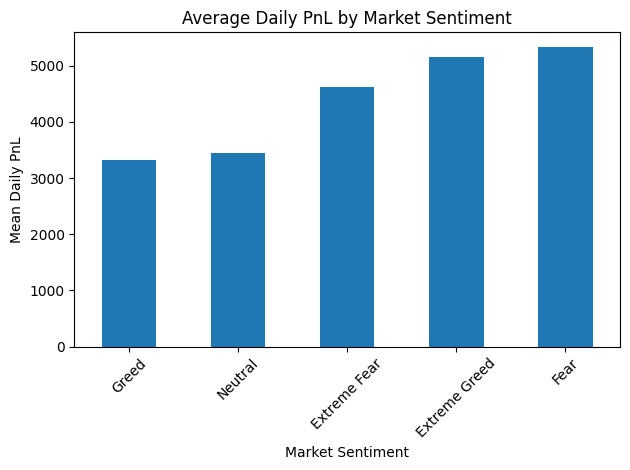

In [26]:
daily_mean = (
    daily_pnl.groupby('classification')['closed_pnl']
    .mean()
    .sort_values()
)

plt.figure()
daily_mean.plot(kind='bar')
plt.title("Average Daily PnL by Market Sentiment")
plt.ylabel("Mean Daily PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
